# 5-fold nested cross-validation over every classification head

This notebook demonstrates how to evaluate **every classification head in
`sliceheads`** with unbiased, nested cross-validation: an outer 5-fold split
for performance estimation, and — independently, inside each outer training
fold — an inner 3-fold split for hyperparameter selection. Per-head
hyperparameter grids, the search strategy, and the dataset path all come
from `experiment.yaml`, not from values hard-coded here.

**You will:** pool the full prepared embedding store, build reproducible
outer/inner `StratifiedKFold` splits, run `GridSearchCV`/`RandomizedSearchCV`
directly on each head (no wrapper — every head is a real sklearn estimator),
capture each scan's out-of-fold predicted probability, and report a pooled
ROC-AUC (with a stratified bootstrap CI) alongside the 5-fold mean ± std of
ROC-AUC, pooled AUPRC (class 0 positive), and pooled balanced accuracy.

This is a long-running notebook (every enabled head, every outer/inner fold,
its full hyperparameter grid) — see the "Running this notebook" note before
Step 4.

## Installation

Install the released package:

In [1]:
# Released version:
# %pip install sliceheads
# For local development instead, from the repo root:
# %pip install -e .

## Imports

Standard libs first, then the package's real public API. Every head below is
a plain sklearn estimator — `sklearn.model_selection` tools are used directly
on it, with no adapter class.

In [2]:
import json
import time
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

from sliceheads.store import EmbedStore, validate_h5
from sliceheads.metrics import compute_metrics
from sliceheads.heads import (
    MeanPoolClassifier,
    MaxPoolClassifier,
    GeMPoolClassifier,
    ABMILClassifier,
    GatedABMILClassifier,
    DSMILClassifier,
    TransformerMILClassifier,
    MultiRocketClassifier,
    InceptionTimeClassifier,
    ALSTMFCNClassifier,
)
from sliceheads.heads.base import BaseHead
from sliceheads.nsr import (
    build_background_pool,
    sample_background_set,
    spawn_scan_seeds,
    dilute_bag,
    logit as nsr_logit,
    pooled_metrics,
)


## Configuration (ALL variables here)

Everything the notebook depends on — paths, seeds, and the nested-CV budget
— is set in this one cell.

In [3]:
# ---- Everything the notebook depends on is set here ----
EXPERIMENT_YAML_PATH = "experiment.yaml"   # per-head hyperparameter grids + run config

with open(EXPERIMENT_YAML_PATH) as fh:
    EXPERIMENT_CONFIG = yaml.safe_load(fh)

H5_PATH         = EXPERIMENT_CONFIG["data"]["h5_path"]              # relative, not absolute
RANDOM_SEED     = EXPERIMENT_CONFIG["training"]["random_seed"]       # <- change in experiment.yaml's training.random_seed, not here
SCORING         = EXPERIMENT_CONFIG["training"]["selection_metric"]  # inner-CV selection metric
SEARCH_STRATEGY = EXPERIMENT_CONFIG["search_strategy"]               # "grid" -> GridSearchCV

N_OUTER_FOLDS   = 5     # outer loop: unbiased performance estimate
N_INNER_FOLDS   = 3     # inner loop: hyperparameter selection only
N_HPO_ITER      = 25    # RandomizedSearchCV budget, only used if SEARCH_STRATEGY != "grid"

FOLDS_PATH           = "folds_mosmed.npz"             # serialized outer-fold indices
CHECKPOINT_PATH      = "nested_cv_checkpoint.json"    # per-fold aggregate metrics, written incrementally
OOF_CHECKPOINT_PATH  = "nested_cv_oof_checkpoint.json"  # per-scan OOF probabilities, written incrementally
OOF_PREDICTIONS_CSV  = "nested_cv_oof_predictions.csv"  # final long-format OOF predictions (head, scan_id, fold, true_label, prob_class_0/1)
SUMMARY_CSV          = "nested_cv_summary.csv"        # per-fold mean/std summary (supplementary)
RESULTS_TABLE_CSV    = "nested_cv_results_table.csv"  # pooled-OOF results table (primary deliverable)
PLOT_PATH            = "nested_cv_roc_auc.png"

N_BOOTSTRAPS    = 2000   # bootstrap resamples for each fold's own 95% ROC-AUC CI (via compute_metrics)
CI_LEVEL        = 0.95

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"device            : {DEVICE}")
print(f"H5_PATH           : {H5_PATH}  (from {EXPERIMENT_YAML_PATH})")
print(f"random_seed       : {RANDOM_SEED}")
print(f"selection_metric  : {SCORING}")
print(f"search_strategy   : {SEARCH_STRATEGY}")

device            : cuda
H5_PATH           : demo_output/prepared_embeddings_full.h5  (from experiment.yaml)
random_seed       : 42
selection_metric  : roc_auc
search_strategy   : grid


In [4]:
# ---- NSR (Noise-to-Signal Ratio) Robustness Analysis config (Step 7) ----
# Step 7 measures how much each head's discrimination degrades when
# task-irrelevant background slice embeddings (drawn from class-0 scans in
# the corresponding outer-training partition) are appended to outer-fold
# test scans, reusing the exact frozen model fitted for that fold in Step 4
# — no retraining. Set nsr.enabled: false in experiment.yaml to skip Step 7
# entirely; nothing else in this notebook is affected.
NSR_CFG = EXPERIMENT_CONFIG.get("nsr", {})
NSR_ENABLED              = NSR_CFG.get("enabled", False)
NSR_DILUTION_LEVELS      = NSR_CFG.get("dilution_levels", [50, 100, 150])
NSR_N_REPEATS            = NSR_CFG.get("n_repeats", 10)
NSR_SEED_BASE            = NSR_CFG.get("seed_base", 42)
NSR_BACKGROUND_POOL_SIZE = max(NSR_DILUTION_LEVELS)

NSR_FROZEN_MODELS_DIR    = Path("nsr_frozen_models")   # fold_{k}/{head_name}/ -> BaseHead.save() output
NSR_MANIFEST_CSV         = "nsr_background_manifest.csv"       # compact: one row per (outer_fold, repeat, scan_id) — seed only, no exploded slice rows
NSR_SELECTIONS_PARQUET   = "nsr_background_selections.parquet"  # optional: exact 150-slice selection per (outer_fold, repeat, scan_id), as list columns
NSR_OOF_PREDICTIONS_CSV  = "nsr_oof_predictions.csv"
NSR_SUMMARY_CSV          = "nsr_robustness_summary.csv"
NSR_ROC_PLOT_PATH        = "nsr_roc_auc_by_dilution.png"
NSR_DELTA_PLOT_PATH      = "nsr_delta_roc_auc.png"

print(f"NSR robustness analysis : {'enabled' if NSR_ENABLED else 'disabled'}")
if NSR_ENABLED:
    print(f"  dilution_levels (b)   : {NSR_DILUTION_LEVELS}")
    print(f"  n_repeats             : {NSR_N_REPEATS}")
    print(f"  seeds                 : {NSR_SEED_BASE}..{NSR_SEED_BASE + NSR_N_REPEATS - 1}")
    print(f"  frozen models dir     : {NSR_FROZEN_MODELS_DIR}/")


NSR robustness analysis : enabled
  dilution_levels (b)   : [50, 100, 150]
  n_repeats             : 10
  seeds                 : 42..51
  frozen models dir     : nsr_frozen_models/


## Input format

`H5_PATH` is an HDF5 store with one group per sample, written by
`sliceheads.store.EmbedStore`:

```
prepared_embeddings_full.h5
 ├── study_0001
 │    ├── embeddings: [num_slices, embedding_dim]   # e.g. [43, 768]
 │    └── attrs: label, split, patient_id
 └── ...
```

- **Source:** MosMedData-derived demo CT dataset, DINOv3 slice embeddings
  (see `prepare_hdf5_embeddings.ipynb`).
- **Labels:** binary — 0 = CT0 (no CT signs of pneumonia), 1 = CT12 (any involvement).
- **Split:** the file carries a `train`/`val`/`test` attribute per sample, but
  nested cross-validation builds its *own* outer/inner splits from scratch —
  see `materials_and_methods.txt`, which notes that `sliceheads` deliberately
  does not implement nested CV internally and instead expects the caller to
  drive it. So this notebook pools **every** sample from the file, ignoring
  the stored split, and re-splits it below with `StratifiedKFold`.

## Step 1 — Validate and load the full dataset

`validate_h5` checks the schema; `EmbedStore.load_split` returns one
variable-length `[N_i, D]` array per sample. We call it once per stored split
and concatenate the three lists, since nested CV re-splits everything itself.

In [5]:
validate_h5(H5_PATH)
print("Validation passed ✓")

store = EmbedStore(H5_PATH)

embeddings_all, labels_all, ids_all = [], [], []
for split in ("train", "val", "test"):
    emb, y, ids = store.load_split(split)
    embeddings_all += emb
    labels_all += list(y)
    ids_all += ids

labels_all = np.array(labels_all, dtype=np.int64)
embedding_dim = embeddings_all[0].shape[1]

# X as a 1-D object array: sklearn's CV splitters index it like any other X,
# each element stays a ragged [N_i, embedding_dim] array — no padding here.
X_all = np.empty(len(embeddings_all), dtype=object)
for i, e in enumerate(embeddings_all):
    X_all[i] = e

print(f"total samples : {len(X_all)}")
print(f"embedding_dim : {embedding_dim}")
print(f"class balance : {dict(zip(*np.unique(labels_all, return_counts=True)))}")

Validation passed ✓


total samples : 1063
embedding_dim : 768
class balance : {np.int64(0): np.int64(254), np.int64(1): np.int64(809)}


## Step 2 — Per-head hyperparameter search spaces

Each head's search space now comes directly from `experiment.yaml` (the
`heads.<name>.hyperparameters` block, for every head with `enabled: true`)
— not from grids hard-coded in this notebook. To change what gets searched,
edit the YAML, not this cell. `experiment.yaml` also declares
`search_strategy: grid`; every enabled head's grid there is small enough
(a few configurations to a few dozen) that `GridSearchCV` searches it
exhaustively. `RandomizedSearchCV` with `n_iter=N_HPO_ITER` remains as a
fallback, used automatically if `search_strategy` is ever set to anything
other than `"grid"`. Fixed training-budget arguments not meant to be
searched (`max_epochs`, `patience`, `input_dim`, `device`, `random_seed`)
are still supplied at construction time.

In [6]:
HEAD_CLASSES = {
    "MeanPoolClassifier": MeanPoolClassifier,
    "MaxPoolClassifier": MaxPoolClassifier,
    "GeMPoolClassifier": GeMPoolClassifier,
    "MultiRocketClassifier": MultiRocketClassifier,
    "ABMILClassifier": ABMILClassifier,
    "GatedABMILClassifier": GatedABMILClassifier,
    "DSMILClassifier": DSMILClassifier,
    "TransformerMILClassifier": TransformerMILClassifier,
    "InceptionTimeClassifier": InceptionTimeClassifier,
    "ALSTMFCNClassifier": ALSTMFCNClassifier,
}

# Heads whose constructor takes input_dim/device (the PyTorch heads); the
# sklearn-pooling heads and the aeon head don't.
NEEDS_INPUT_DIM_DEVICE = {
    "ABMILClassifier", "GatedABMILClassifier", "DSMILClassifier",
    "TransformerMILClassifier", "InceptionTimeClassifier", "ALSTMFCNClassifier",
}

HEAD_SEARCH_SPACES = {}
for head_name, head_cfg in EXPERIMENT_CONFIG["heads"].items():
    if not head_cfg.get("enabled", False):
        continue
    cls = HEAD_CLASSES[head_name]
    kwargs = {"random_seed": RANDOM_SEED}
    if head_name in NEEDS_INPUT_DIM_DEVICE:
        kwargs.update(input_dim=embedding_dim, device=DEVICE)
    param_grid = {k: list(v) for k, v in head_cfg["hyperparameters"].items()}
    HEAD_SEARCH_SPACES[head_name] = (cls(**kwargs), param_grid)

for name, (_, grid) in HEAD_SEARCH_SPACES.items():
    n_combos = 1
    for values in grid.values():
        n_combos *= len(values)
    use_grid = SEARCH_STRATEGY == "grid" or n_combos <= N_HPO_ITER
    strategy = "GridSearchCV (exhaustive)" if use_grid else f"RandomizedSearchCV (n_iter={N_HPO_ITER})"
    print(f"{name:<26s} {n_combos:>4d} configs  ->  {strategy}")

MeanPoolClassifier            5 configs  ->  GridSearchCV (exhaustive)
MaxPoolClassifier             4 configs  ->  GridSearchCV (exhaustive)
GeMPoolClassifier             9 configs  ->  GridSearchCV (exhaustive)
ABMILClassifier              12 configs  ->  GridSearchCV (exhaustive)
GatedABMILClassifier          4 configs  ->  GridSearchCV (exhaustive)
DSMILClassifier               4 configs  ->  GridSearchCV (exhaustive)
TransformerMILClassifier      4 configs  ->  GridSearchCV (exhaustive)
InceptionTimeClassifier       4 configs  ->  GridSearchCV (exhaustive)
ALSTMFCNClassifier            4 configs  ->  GridSearchCV (exhaustive)
MultiRocketClassifier         3 configs  ->  GridSearchCV (exhaustive)


## Step 3 — Outer 5-fold split, serialized to disk

`StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)` gives
the outer performance-estimation folds. The indices are saved to
`folds_mosmed.npz` so the exact split can be reused or audited later without
re-running the notebook.

In [7]:
outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_SEED)
outer_folds = list(outer_cv.split(X_all, labels_all))

folds_to_save = {}
for i, (train_idx, test_idx) in enumerate(outer_folds):
    folds_to_save[f"fold_{i}_train"] = train_idx
    folds_to_save[f"fold_{i}_test"] = test_idx
np.savez(FOLDS_PATH, **folds_to_save)

for i, (train_idx, test_idx) in enumerate(outer_folds):
    print(f"outer fold {i}: train={len(train_idx):4d}  test={len(test_idx):4d}")
print(f"\nfold indices written to {FOLDS_PATH}")

# Every scan must land in exactly one outer fold's test partition — this is
# what lets the pooled OOF vector (Step 6) be built by straight concatenation.
all_test_idx = np.concatenate([test_idx for _, test_idx in outer_folds])
assert len(all_test_idx) == len(X_all), "outer test folds do not cover the full cohort"
assert len(np.unique(all_test_idx)) == len(all_test_idx), "a scan appears in more than one outer test fold"
print("outer test folds: cover the full cohort, each scan exactly once ✓")

outer fold 0: train= 850  test= 213
outer fold 1: train= 850  test= 213
outer fold 2: train= 850  test= 213
outer fold 3: train= 851  test= 212
outer fold 4: train= 851  test= 212

fold indices written to folds_mosmed.npz
outer test folds: cover the full cohort, each scan exactly once ✓


## Step 4 — Nested cross-validation

For every outer fold: build a fresh inner `StratifiedKFold(3)`, then for
every head, run its `GridSearchCV` (or `RandomizedSearchCV`, per
`experiment.yaml`'s `search_strategy`) on the outer-training fold only,
refit the best configuration, and evaluate once on the held-out outer-test
fold with `compute_metrics` (which includes a 95% bootstrap ROC-AUC CI
computed *within that fold*). Results are appended to `CHECKPOINT_PATH`
after every single head/fold so progress survives an interruption.

**Per-scan OOF predictions.** This loop also records each held-out scan's
predicted probability, keyed by `scan_id`, into `oof_predictions` —
checkpointed to `OOF_CHECKPOINT_PATH` the same way, every head/fold.
Without this, there would be no way to pool predictions across the 5 outer
folds into one N=1063-length vector per head for Step 6's pooled ROC-AUC
and its bootstrap CI — aggregated per-fold metrics alone can't be
un-aggregated after the fact, which is why this notebook previously
couldn't produce that table.

**Running this notebook:** 5 outer folds x every enabled head x its full
hyperparameter grid is thousands of individual model fits. On this
machine's GPU it takes on the order of an hour; on CPU, considerably
longer — long enough that you should launch it as a background process
(e.g.
`nohup jupyter nbconvert --to notebook --execute --inplace 05_nested_cross_validation.ipynb &`)
rather than run it interactively cell-by-cell.

In [8]:
fold_metrics = {name: [] for name in HEAD_SEARCH_SPACES}
best_params_log = {name: [] for name in HEAD_SEARCH_SPACES}
oof_predictions = {name: {} for name in HEAD_SEARCH_SPACES}  # head -> scan_id -> {fold, true_label, prob_class_0, prob_class_1}
NSR_FROZEN_MODEL_MTIMES = {}  # (fold_i, head_name) -> manifest.json mtime right after saving; Step 7d checks this never changes

start_all = time.time()

for fold_i, (train_idx, test_idx) in enumerate(outer_folds):
    X_train_outer, X_test_outer = X_all[train_idx], X_all[test_idx]
    y_train_outer, y_test_outer = labels_all[train_idx], labels_all[test_idx]
    ids_test_outer = [ids_all[i] for i in test_idx]
    inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_SEED + fold_i)

    for head_name, (estimator, param_grid) in HEAD_SEARCH_SPACES.items():
        t0 = time.time()

        n_combos = 1
        for values in param_grid.values():
            n_combos *= len(values)

        if SEARCH_STRATEGY == "grid" or n_combos <= N_HPO_ITER:
            search = GridSearchCV(
                estimator, param_grid, scoring=SCORING, cv=inner_cv,
                n_jobs=1, error_score=np.nan,
            )
            strategy = "grid"
        else:
            search = RandomizedSearchCV(
                estimator, param_grid, n_iter=N_HPO_ITER, scoring=SCORING, cv=inner_cv,
                random_state=RANDOM_SEED + fold_i, n_jobs=1, error_score=np.nan,
            )
            strategy = "random"

        search.fit(X_train_outer, y_train_outer)

        # Freeze this fold's best-fitted head to disk for Step 7's NSR
        # robustness analysis — reused as-is there, never refit. Purely
        # additive: nothing below this line or in Step 4b/5/6 changes.
        if NSR_ENABLED:
            frozen_path = NSR_FROZEN_MODELS_DIR / f"fold_{fold_i}" / head_name
            search.best_estimator_.save(str(frozen_path))
            NSR_FROZEN_MODEL_MTIMES[(fold_i, head_name)] = (frozen_path / "manifest.json").stat().st_mtime

        proba = search.best_estimator_.predict_proba(X_test_outer)
        m = compute_metrics(y_test_outer, proba, n_bootstraps=N_BOOTSTRAPS, ci=CI_LEVEL, random_seed=RANDOM_SEED)

        fold_metrics[head_name].append(m)
        best_params_log[head_name].append(search.best_params_)

        for sid, yt, p in zip(ids_test_outer, y_test_outer, proba):
            oof_predictions[head_name][sid] = {
                "fold": fold_i,
                "true_label": int(yt),
                "prob_class_0": float(p[0]),
                "prob_class_1": float(p[1]),
            }

        elapsed = time.time() - t0
        print(
            f"[fold {fold_i + 1}/{N_OUTER_FOLDS}] {head_name:<26s} "
            f"({strategy}, {n_combos} configs)  inner_best={search.best_score_:.3f}  "
            f"test_roc_auc={m['roc_auc']:.3f}  ({elapsed:.1f}s)",
            flush=True,
        )

        # Checkpoint after every head/fold so progress survives an interruption.
        with open(CHECKPOINT_PATH, "w") as fh:
            json.dump(fold_metrics, fh, indent=2)
        with open(OOF_CHECKPOINT_PATH, "w") as fh:
            json.dump(oof_predictions, fh, indent=2)

total_hours = (time.time() - start_all) / 3600
print(f"\nTotal nested CV runtime: {total_hours:.2f} hours")

[fold 1/5] MeanPoolClassifier         (grid, 5 configs)  inner_best=0.829  test_roc_auc=0.872  (3.8s)


[fold 1/5] MaxPoolClassifier          (grid, 4 configs)  inner_best=0.782  test_roc_auc=0.873  (3.0s)


[fold 1/5] GeMPoolClassifier          (grid, 9 configs)  inner_best=0.825  test_roc_auc=0.885  (6.3s)


[fold 1/5] ABMILClassifier            (grid, 12 configs)  inner_best=0.726  test_roc_auc=0.752  (9.3s)


[fold 1/5] GatedABMILClassifier       (grid, 4 configs)  inner_best=0.728  test_roc_auc=0.785  (4.8s)


...

[fold 5/5] TransformerMILClassifier   (grid, 4 configs)  inner_best=0.736  test_roc_auc=0.799  (9.0s)


[fold 5/5] InceptionTimeClassifier    (grid, 4 configs)  inner_best=0.830  test_roc_auc=0.863  (6.9s)


[fold 5/5] ALSTMFCNClassifier         (grid, 4 configs)  inner_best=0.820  test_roc_auc=0.841  (5.7s)


[fold 5/5] MultiRocketClassifier      (grid, 3 configs)  inner_best=0.682  test_roc_auc=0.717  (59.3s)



Total nested CV runtime: 0.16 hours


## Step 4b — Persist per-scan OOF predictions

Flatten `oof_predictions` into a long-format table (`scan_id`, `head`,
`fold`, `true_label`, `prob_class_0`, `prob_class_1`) and write it to
`OOF_PREDICTIONS_CSV`. The assertions below are the alignment guarantees
Step 6 depends on: every head must have exactly one OOF row per scan, and
that set of scans must be the full cohort — not just "the right count."

In [9]:
oof_rows = []
for head_name, preds in oof_predictions.items():
    for sid, p in preds.items():
        oof_rows.append({
            "scan_id": sid,
            "head": head_name,
            "fold": p["fold"],
            "true_label": p["true_label"],
            "prob_class_0": p["prob_class_0"],
            "prob_class_1": p["prob_class_1"],
        })
oof_df = pd.DataFrame(oof_rows)
oof_df.to_csv(OOF_PREDICTIONS_CSV, index=False)

# Every head must have exactly one row per scan, and that set of scans must
# be the full cohort — otherwise pooling/alignment in Step 6 is unsound.
for head_name in HEAD_SEARCH_SPACES:
    head_ids = oof_df.loc[oof_df["head"] == head_name, "scan_id"]
    assert len(head_ids) == len(ids_all), f"{head_name}: {len(head_ids)} OOF predictions, expected {len(ids_all)}"
    assert head_ids.is_unique, f"{head_name}: duplicate scan IDs in OOF predictions"
    assert set(head_ids) == set(ids_all), f"{head_name}: OOF scan IDs don't match the full cohort"

print(f"OOF predictions: {len(HEAD_SEARCH_SPACES)} heads x {len(ids_all)} scans, written to {OOF_PREDICTIONS_CSV}")

OOF predictions: 10 heads x 1063 scans, written to nested_cv_oof_predictions.csv


## Step 5 — Per-fold aggregate summary (supplementary)

For each head, the 5 outer-fold test metrics are summarized as mean ± std:
ROC-AUC, its 95% bootstrap CI (lower/upper bound, each reported as mean ± std
across folds — a *per-fold* CI, distinct from Step 6's pooled-OOF CI),
balanced accuracy, and per-class F1. Written to `SUMMARY_CSV` for the
per-class F1 detail that Step 6's pooled table doesn't carry; Step 6 is the
primary results table.

In [10]:
def summarize(folds):
    keys = (
        "roc_auc", "roc_auc_ci_lower", "roc_auc_ci_upper",
        "balanced_accuracy", "f1_class_0", "f1_class_1",
    )
    values = {k: np.array([f[k] for f in folds]) for k in keys}
    summary = {}
    for k in keys:
        summary[f"{k}_mean"] = values[k].mean()
        summary[f"{k}_std"] = values[k].std(ddof=1)
    return summary


rows = []
for head_name, folds in fold_metrics.items():
    s = summarize(folds)
    rows.append({
        "Head": head_name,
        "ROC-AUC": f"{s['roc_auc_mean']:.3f} ± {s['roc_auc_std']:.3f}",
        "95% CI": (
            f"[{s['roc_auc_ci_lower_mean']:.3f} ± {s['roc_auc_ci_lower_std']:.3f}, "
            f"{s['roc_auc_ci_upper_mean']:.3f} ± {s['roc_auc_ci_upper_std']:.3f}]"
        ),
        "Balanced Accuracy": f"{s['balanced_accuracy_mean']:.3f} ± {s['balanced_accuracy_std']:.3f}",
        "F1 (class 0)": f"{s['f1_class_0_mean']:.3f} ± {s['f1_class_0_std']:.3f}",
        "F1 (class 1)": f"{s['f1_class_1_mean']:.3f} ± {s['f1_class_1_std']:.3f}",
    })

df_summary = pd.DataFrame(rows).set_index("Head")
df_summary.to_csv(SUMMARY_CSV)
df_summary

,ROC-AUC,95% CI,Balanced Accuracy,F1 (class 0),F1 (class 1)
Head,,,,,
MeanPoolClassifier,0.854 ± 0.022,"[0.796 ± 0.029, 0.906 ± 0.016]",0.761 ± 0.042,0.612 ± 0.051,0.850 ± 0.019
MaxPoolClassifier,0.815 ± 0.035,"[0.745 ± 0.041, 0.878 ± 0.028]",0.727 ± 0.039,0.571 ± 0.051,0.839 ± 0.022
GeMPoolClassifier,0.844 ± 0.026,"[0.782 ± 0.030, 0.900 ± 0.022]",0.756 ± 0.040,0.608 ± 0.048,0.853 ± 0.015
ABMILClassifier,0.732 ± 0.033,"[0.650 ± 0.040, 0.809 ± 0.027]",0.665 ± 0.024,0.488 ± 0.031,0.801 ± 0.016
GatedABMILClassifier,0.739 ± 0.051,"[0.658 ± 0.059, 0.812 ± 0.044]",0.663 ± 0.049,0.486 ± 0.060,0.791 ± 0.029
DSMILClassifier,0.721 ± 0.023,"[0.633 ± 0.028, 0.806 ± 0.019]",0.679 ± 0.024,0.504 ± 0.026,0.786 ± 0.020
TransformerMILClassifier,0.779 ± 0.054,"[0.704 ± 0.068, 0.847 ± 0.042]",0.713 ± 0.047,0.542 ± 0.052,0.801 ± 0.009
InceptionTimeClassifier,0.848 ± 0.028,"[0.790 ± 0.036, 0.901 ± 0.021]",0.740 ± 0.027,0.585 ± 0.033,0.834 ± 0.022
ALSTMFCNClassifier,0.835 ± 0.027,"[0.772 ± 0.036, 0.893 ± 0.020]",0.718 ± 0.027,0.564 ± 0.036,0.852 ± 0.016


### Visualize ROC-AUC by head

A horizontal bar chart, sorted best-to-worst, with the 5-fold std as error
bars.

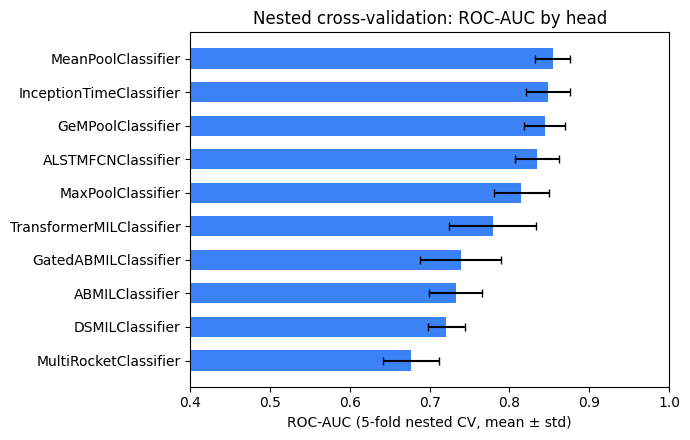

In [11]:
roc_auc_mean = {name: np.mean([f["roc_auc"] for f in folds]) for name, folds in fold_metrics.items()}
roc_auc_std = {name: np.std([f["roc_auc"] for f in folds], ddof=1) for name, folds in fold_metrics.items()}

order = sorted(roc_auc_mean, key=roc_auc_mean.get)
means = [roc_auc_mean[n] for n in order]
stds = [roc_auc_std[n] for n in order]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(order, means, xerr=stds, color="#3B82F6", edgecolor="none", height=0.6, capsize=3)
ax.set_xlabel("ROC-AUC (5-fold nested CV, mean ± std)")
ax.set_xlim(0.4, 1.0)
ax.set_title("Nested cross-validation: ROC-AUC by head")
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150)
plt.show()

## Step 6 — Pooled-OOF results table (primary deliverable)

One row per head, **sorted by pooled ROC-AUC descending**, built from the
per-scan OOF predictions (Step 4b) rather than from aggregated per-fold
metrics:

- **`roc_auc_pooled` + 95% CI** — concatenate every head's 5 outer-fold OOF
  predictions into one length-N (N=1063) vector, aligned by `scan_id` (not
  positional order — enforced by the asserts below, on top of the Step 4b
  asserts). The point estimate is the ROC-AUC on that full pooled vector.
  The CI is the 2.5/97.5 percentile of `N_POOLED_BOOTSTRAPS` resamples,
  each stratified by class label (resampling *scans*, never slices) and
  reusing the *same* resampled indices across every head within a given
  iteration, so head-to-head comparisons stay paired. `POOLED_BOOTSTRAP_SEED`
  is recorded below.
- **`roc_auc_fold_mean` ± `std`** — plain mean/std of the 5 per-outer-fold
  ROC-AUC values already computed in Step 4 (`fold_metrics`), **not** from
  the bootstrap. This is a deliberately different quantity from the pooled
  CI above — fold-to-fold variability vs. overall pooled discrimination —
  and both belong in the table.
- **`auprc_class0`** — average precision with class 0 (CT-0, the 23.9%
  minority) as the positive class, on the pooled OOF vector. Uses
  `prob_class_0` scored against `true_label == 0`, not the default
  class-1-positive convention.
- **`balanced_accuracy`** — at the fixed 0.5 threshold (`prob_class_1 >=
  0.5`), matching what `head.predict()` does internally, on the pooled OOF
  vector.

In [12]:
N_POOLED_BOOTSTRAPS = 2000
POOLED_BOOTSTRAP_SEED = RANDOM_SEED
print(f"pooled-OOF bootstrap: n_resamples={N_POOLED_BOOTSTRAPS}  seed={POOLED_BOOTSTRAP_SEED}")

# scan_id -> true_label, fixed across all heads (every head shares the same outer folds)
y_pooled_by_id = oof_df.drop_duplicates("scan_id").set_index("scan_id")["true_label"].loc[ids_all]
y_pooled = y_pooled_by_id.to_numpy()

proba1_pool = {}  # head -> [N] prob_class_1, row-aligned to ids_all
proba0_pool = {}  # head -> [N] prob_class_0, row-aligned to ids_all
for head_name in HEAD_SEARCH_SPACES:
    head_df = oof_df[oof_df["head"] == head_name].set_index("scan_id").loc[ids_all]
    assert (head_df["true_label"].to_numpy() == y_pooled).all(), f"{head_name}: label mismatch after alignment"
    proba1_pool[head_name] = head_df["prob_class_1"].to_numpy()
    proba0_pool[head_name] = head_df["prob_class_0"].to_numpy()

# Stratified bootstrap: resample scans within each class, reusing the same
# resampled indices across every head within an iteration.
rng = np.random.default_rng(POOLED_BOOTSTRAP_SEED)
class0_idx = np.where(y_pooled == 0)[0]
class1_idx = np.where(y_pooled == 1)[0]
boot_indices = [
    np.concatenate([
        rng.choice(class0_idx, size=len(class0_idx), replace=True),
        rng.choice(class1_idx, size=len(class1_idx), replace=True),
    ])
    for _ in range(N_POOLED_BOOTSTRAPS)
]

rows = []
for head_name in HEAD_SEARCH_SPACES:
    y1, y0 = proba1_pool[head_name], proba0_pool[head_name]

    roc_auc_pooled = roc_auc_score(y_pooled, y1)
    boot_aucs = np.array([roc_auc_score(y_pooled[idx], y1[idx]) for idx in boot_indices])
    ci_lo, ci_hi = np.percentile(boot_aucs, [2.5, 97.5])

    fold_aucs = np.array([f["roc_auc"] for f in fold_metrics[head_name]])

    auprc_class0 = average_precision_score((y_pooled == 0).astype(int), y0)
    balanced_acc = balanced_accuracy_score(y_pooled, (y1 >= 0.5).astype(int))

    rows.append({
        "head": head_name,
        "roc_auc_pooled": roc_auc_pooled,
        "roc_auc_pooled_ci_low": ci_lo,
        "roc_auc_pooled_ci_high": ci_hi,
        "roc_auc_fold_mean": fold_aucs.mean(),
        "roc_auc_fold_std": fold_aucs.std(ddof=1),
        "auprc_class0": auprc_class0,
        "balanced_accuracy": balanced_acc,
    })

results_table = pd.DataFrame(rows).sort_values("roc_auc_pooled", ascending=False).reset_index(drop=True)
results_table.to_csv(RESULTS_TABLE_CSV, index=False)

results_table_display = pd.DataFrame({
    "head": results_table["head"],
    "roc_auc_pooled + 95% CI": [
        f"{a:.3f} [{lo:.3f}, {hi:.3f}]"
        for a, lo, hi in zip(
            results_table["roc_auc_pooled"],
            results_table["roc_auc_pooled_ci_low"],
            results_table["roc_auc_pooled_ci_high"],
        )
    ],
    "roc_auc_fold_mean ± std": [
        f"{m:.3f} ± {s:.3f}"
        for m, s in zip(results_table["roc_auc_fold_mean"], results_table["roc_auc_fold_std"])
    ],
    "auprc_class0": results_table["auprc_class0"].map("{:.3f}".format),
    "balanced_accuracy": results_table["balanced_accuracy"].map("{:.3f}".format),
}).set_index("head")

print(f"results table written to {RESULTS_TABLE_CSV}")
results_table_display

pooled-OOF bootstrap: n_resamples=2000  seed=42


results table written to nested_cv_results_table.csv


,roc_auc_pooled + 95% CI,roc_auc_fold_mean ± std,auprc_class0,balanced_accuracy
head,,,,
MeanPoolClassifier,"0.853 [0.828, 0.878]",0.854 ± 0.022,0.632,0.761
InceptionTimeClassifier,"0.847 [0.822, 0.871]",0.848 ± 0.028,0.624,0.740
GeMPoolClassifier,"0.843 [0.815, 0.869]",0.844 ± 0.026,0.627,0.756
ALSTMFCNClassifier,"0.825 [0.796, 0.853]",0.835 ± 0.027,0.569,0.718
MaxPoolClassifier,"0.815 [0.785, 0.845]",0.815 ± 0.035,0.602,0.727
TransformerMILClassifier,"0.776 [0.744, 0.808]",0.779 ± 0.054,0.527,0.712
GatedABMILClassifier,"0.739 [0.704, 0.774]",0.739 ± 0.051,0.463,0.663
ABMILClassifier,"0.721 [0.684, 0.757]",0.732 ± 0.033,0.465,0.665
DSMILClassifier,"0.716 [0.678, 0.756]",0.721 ± 0.023,0.460,0.678


## Step 7 — Noise-to-Signal Ratio (NSR) Robustness Analysis

*(Only runs if `nsr.enabled: true` in `experiment.yaml` — set it to `false`
to skip this whole section; nothing above or below it depends on it.)*

**"Noise" here means appended task-irrelevant background slice embeddings,
not Gaussian numerical noise.** For every outer fold and every enabled
head, this section reuses the exact best-fitted model frozen to disk in
Step 4 (`search.best_estimator_.save(...)`, added there) — **no
retraining** — and asks: what happens to that model's discrimination when
`b` extra background slices, drawn only from **class-0 (negative) scans in
that fold's outer-training partition**, are appended after each outer-test
scan's own slices?

**Each test scan draws its own independent background set.** For every
outer fold x repeat x test scan, a fresh set of `max(dilution_levels)`
background slices is sampled from that fold's outer-train class-0 pool,
using a child seed spawned from the repeat's seed
(`sliceheads.nsr.spawn_scan_seeds`) — so scan *i* and scan *j* in the same
fold/repeat never see the same injected slices. This is deliberate: a
single background set shared across every test scan in a fold/repeat would
let all scans absorb the *identical* injected signal, which could
artificially favor aggregation/pooling heads over heads that are more
sensitive to per-sample variation. Within one scan's own draw, `b in
NSR_DILUTION_LEVELS` slices a prefix of that *one* draw — so `B_50 ⊂ B_100 ⊂
B_150` holds per scan, exactly as before. The same background is still
reused across every head and every b for a given (fold, repeat, scan), so
head-to-head and b-to-b comparisons stay paired. `b=0` is the untouched
baseline and is **not** recomputed per repeat — it's the OOF prediction
already computed in Step 4. A scan's own slices are never removed,
reordered, or modified — only appended to.

**The background manifest is compact, not exploded per slice.** Since
sampling is fully deterministic from `(outer_fold, repeat, scan_id, seed)` —
`sample_background_set(NSR_BACKGROUND_POOLS[outer_fold], NSR_BACKGROUND_POOL_SIZE,
spawn_scan_seeds(seed, n_test_scans_in_fold)[scan_index_in_fold])`
reproduces the exact same 150-slice draw every time — `NSR_MANIFEST_CSV`
stores just one row per `(outer_fold, repeat, scan_id)` with the seed and
enough metadata to regenerate the draw, never one row per background slice
(which would be ~150x more rows). The exact selections are still available
if needed without recomputation, in `NSR_SELECTIONS_PARQUET` — one row per
scan with `source_scan_id` / `source_slice_index` as list-typed columns,
not exploded rows (a plain CSV can't hold list-typed cells cleanly, hence
Parquet).

After all folds, predictions are pooled per (head, repeat, b) exactly like
Step 6, and scored with the same `compute_metrics` conventions used
throughout this notebook (`prob_class_1` positive, 0.5 operating point).
`ΔROC-AUC` (and the analogous `ΔAUPRC` / `Δbalanced-accuracy`) =
`metric(b) − metric(0)` for the *same repeat*; mean/SD are then taken
**across the repeats** — the metric is always computed once per complete
OOF repetition first, never from predictions averaged across repeats.
ROC-AUC (and its Δ) is the outcome that answers whether discrimination
degrades toward chance; the per-scan Δlogit stored alongside it is only a
confidence-shift diagnostic, not evidence of chance-level classification on
its own.

In [13]:
NSR_BACKGROUND_POOLS = {}  # fold_i -> BackgroundPool (class-0 scans of that fold's outer-train partition only)

if NSR_ENABLED:
    for fold_i, (train_idx, test_idx) in enumerate(outer_folds):
        train_ids = [ids_all[i] for i in train_idx]
        test_ids = {ids_all[i] for i in test_idx}

        pool = build_background_pool(
            [X_all[i] for i in train_idx], labels_all[train_idx], train_ids,
        )
        NSR_BACKGROUND_POOLS[fold_i] = pool

        # Validation #1: background source scans never come from this fold's outer-test partition.
        assert not (set(pool.source_scan_id) & test_ids), \
            f"fold {fold_i}: background pool leaks outer-test scans"
        assert set(pool.source_scan_id) <= set(train_ids), \
            f"fold {fold_i}: background pool references scans outside outer-train"

        print(
            f"fold {fold_i}: background pool = {len(pool):5d} slices from "
            f"{len(set(pool.source_scan_id)):3d} class-0 outer-train scans"
        )

    print("\nvalidation #1: background sources never overlap outer-test folds ✓")

fold 0: background pool =  8859 slices from 203 class-0 outer-train scans
fold 1: background pool =  8832 slices from 203 class-0 outer-train scans
fold 2: background pool =  8884 slices from 203 class-0 outer-train scans
fold 3: background pool =  8921 slices from 203 class-0 outer-train scans
fold 4: background pool =  8868 slices from 204 class-0 outer-train scans

validation #1: background sources never overlap outer-test folds ✓


### Step 7b — Per-scan background sampling + diluted inference

For every outer fold: load each head's frozen model once (reused across all
repeats — never refit). For every repeat: every test scan spawns its own
child seed (`spawn_scan_seeds`) and draws its own independent
`NSR_BACKGROUND_POOL_SIZE`-length background set from that fold's class-0
pool (`sample_background_set`). Rather than recording every drawn slice as
its own manifest row, only the seed and positional metadata needed to
regenerate the draw are kept for `NSR_MANIFEST_CSV` — one compact row per
`(outer_fold, repeat, scan_id)`; the exact selections are kept separately in
`NSR_SELECTIONS_PARQUET` (list columns, still one row per scan) for
inspection without recomputation. That one draw per scan is reused, sliced
to a prefix, for every `b` and every head, so `B_50 ⊂ B_100 ⊂ B_150` holds
per scan and comparisons across heads/b stay paired. Baseline (`b=0`) rows
reuse Step 4/4b's already-computed OOF predictions. Inference stays
batched — `head.predict_proba` is still called once per (fold, repeat,
head, b) over every test scan in that fold, each with its own diluted bag —
so per-scan backgrounds don't multiply the number of inference calls versus
a shared-background design.

In [14]:
nsr_manifest_df = None
nsr_selection_df = None
nsr_oof_df = None

if NSR_ENABLED:
    # O(1) baseline lookups instead of re-filtering oof_df per scan (oof_df
    # itself is read-only here — never mutated, per validation #8).
    baseline_prob_lookup = dict(zip(zip(oof_df["head"], oof_df["scan_id"]), oof_df["prob_class_1"]))
    baseline_logit_lookup = {
        (h, s): float(lg)
        for h, s, lg in zip(oof_df["head"], oof_df["scan_id"], nsr_logit(oof_df["prob_class_1"].to_numpy()))
    }

    # One row per (outer_fold, repeat, scan_id): seed + positional metadata
    # only — the exact 150-slice draw is fully reproducible from this row
    # via sample_background_set(NSR_BACKGROUND_POOLS[outer_fold],
    # NSR_BACKGROUND_POOL_SIZE, spawn_scan_seeds(seed, n_test)[scan_index_in_fold]),
    # so this never explodes to one row per background slice.
    nsr_selection_rows = []
    nsr_pred_rows = []

    for fold_i, (train_idx, test_idx) in enumerate(outer_folds):
        ids_test_outer = [ids_all[i] for i in test_idx]
        y_test_outer = labels_all[test_idx]
        X_test_outer = [X_all[i] for i in test_idx]
        pool = NSR_BACKGROUND_POOLS[fold_i]
        n_test = len(ids_test_outer)

        # Baseline (b=0): reused from Step 4/4b, not recomputed.
        for head_name in HEAD_SEARCH_SPACES:
            for sid, yt, x in zip(ids_test_outer, y_test_outer, X_test_outer):
                bp = float(baseline_prob_lookup[(head_name, sid)])
                bl = baseline_logit_lookup[(head_name, sid)]
                n_orig = x.shape[0]
                nsr_pred_rows.append({
                    "scan_id": sid, "label": int(yt), "outer_fold": fold_i, "head": head_name,
                    "repeat": None, "seed": None, "b": 0,
                    "original_num_slices": n_orig, "num_appended_slices": 0, "total_num_slices": n_orig,
                    "probability": bp, "logit": bl,
                    "baseline_probability": bp, "baseline_logit": bl, "delta_logit": 0.0,
                })

        # Frozen models: load once per fold, reused across every repeat below.
        heads_loaded = {
            head_name: BaseHead.load(str(NSR_FROZEN_MODELS_DIR / f"fold_{fold_i}" / head_name))
            for head_name in HEAD_SEARCH_SPACES
        }

        for r in range(NSR_N_REPEATS):
            seed = NSR_SEED_BASE + r

            # Each test scan draws its OWN independent background set — never
            # shared across scans — via a per-scan child seed spawned from
            # this repeat's seed. A shared set could artificially favor
            # aggregation/pooling heads, since every scan would then carry
            # the identical injected slices.
            scan_seeds = spawn_scan_seeds(seed, n_test)
            bg_per_scan = []
            for j, sid in enumerate(ids_test_outer):
                bg, manifest = sample_background_set(pool, NSR_BACKGROUND_POOL_SIZE, scan_seeds[j])
                bg_per_scan.append(bg)
                nsr_selection_rows.append({
                    "outer_fold": fold_i, "repeat": r, "seed": seed,
                    "scan_id": sid, "scan_index_in_fold": j,
                    "background_pool_size": NSR_BACKGROUND_POOL_SIZE,
                    "source_scan_id": [row["source_scan_id"] for row in manifest],
                    "source_slice_index": [row["source_slice_index"] for row in manifest],
                })

            for head_name, head in heads_loaded.items():
                for b in NSR_DILUTION_LEVELS:
                    diluted_bags = [dilute_bag(x, bg_per_scan[j], b) for j, x in enumerate(X_test_outer)]
                    proba = head.predict_proba(diluted_bags)
                    scores = proba[:, 1].astype(np.float64)
                    logits = nsr_logit(scores)

                    for sid, yt, x, p, lg in zip(ids_test_outer, y_test_outer, X_test_outer, scores, logits):
                        bp = float(baseline_prob_lookup[(head_name, sid)])
                        bl = baseline_logit_lookup[(head_name, sid)]
                        n_orig = x.shape[0]
                        nsr_pred_rows.append({
                            "scan_id": sid, "label": int(yt), "outer_fold": fold_i, "head": head_name,
                            "repeat": r, "seed": seed, "b": b,
                            "original_num_slices": n_orig, "num_appended_slices": b, "total_num_slices": n_orig + b,
                            "probability": float(p), "logit": float(lg),
                            "baseline_probability": bp, "baseline_logit": bl,
                            "delta_logit": float(bl - lg),
                        })

        print(f"fold {fold_i}: per-scan diluted inference done for {len(HEAD_SEARCH_SPACES)} heads x "
              f"{NSR_N_REPEATS} repeats x {len(NSR_DILUTION_LEVELS)} dilution levels x {n_test} independently-diluted scans", flush=True)

    nsr_selection_df = pd.DataFrame(nsr_selection_rows)

    # Compact seed manifest (CSV) — one row per (outer_fold, repeat,
    # scan_id), never one row per background slice.
    nsr_manifest_df = nsr_selection_df.drop(columns=["source_scan_id", "source_slice_index"])
    nsr_manifest_df.to_csv(NSR_MANIFEST_CSV, index=False)
    print(f"\nbackground seed manifest: {len(nsr_manifest_df)} rows written to {NSR_MANIFEST_CSV}")

    # Optional exact selections, compact (list columns, still one row per
    # scan) — not required for reproducibility, kept for inspection.
    nsr_selection_df.to_parquet(NSR_SELECTIONS_PARQUET, index=False)
    print(f"exact background selections: {len(nsr_selection_df)} rows written to {NSR_SELECTIONS_PARQUET}")

    nsr_oof_df = pd.DataFrame(nsr_pred_rows)
    nsr_oof_df.to_csv(NSR_OOF_PREDICTIONS_CSV, index=False)
    print(f"NSR OOF predictions: {len(nsr_oof_df)} rows written to {NSR_OOF_PREDICTIONS_CSV}")


fold 0: per-scan diluted inference done for 10 heads x 10 repeats x 3 dilution levels x 213 independently-diluted scans


fold 1: per-scan diluted inference done for 10 heads x 10 repeats x 3 dilution levels x 213 independently-diluted scans


fold 2: per-scan diluted inference done for 10 heads x 10 repeats x 3 dilution levels x 213 independently-diluted scans


fold 3: per-scan diluted inference done for 10 heads x 10 repeats x 3 dilution levels x 212 independently-diluted scans


fold 4: per-scan diluted inference done for 10 heads x 10 repeats x 3 dilution levels x 212 independently-diluted scans



background seed manifest: 10630 rows written to nsr_background_manifest.csv
exact background selections: 10630 rows written to nsr_background_selections.parquet


NSR OOF predictions: 329530 rows written to nsr_oof_predictions.csv


### Step 7c — Validation checks

Check #1 (background never sourced from the outer-test fold) already ran
in Step 7a. The remaining checks — including #6 (each scan's background is
independent, not shared) — recompute directly from `(outer_fold, repeat,
scan_id, seed)` via `spawn_scan_seeds` + `sample_background_set`, the same
ground truth the compact manifest relies on for reproducibility, rather
than reading it back from any CSV.

In [15]:
if NSR_ENABLED:
    # Validation #2 + #3 + #5 + #6: original slice embeddings are never
    # removed, modified, or reordered; total_num_slices == N_i + b exactly;
    # each scan's own draw is prefix-nested across b (B_50 subset B_100
    # subset B_150); and each scan's background draw is independent of
    # every other scan's in the same (outer_fold, repeat) — never one set
    # shared across the fold/repeat. Recomputed directly from ground truth
    # (spawn_scan_seeds + sample_background_set + dilute_bag) — this is
    # also the reference implementation of "reproducible from (outer_fold,
    # repeat, scan_id, seed)" that the compact seed manifest relies on.
    for fold_i, (train_idx, test_idx) in enumerate(outer_folds):
        X_test_outer = [X_all[i] for i in test_idx]
        pool = NSR_BACKGROUND_POOLS[fold_i]
        n_test = len(X_test_outer)
        for r in range(NSR_N_REPEATS):
            seed = NSR_SEED_BASE + r
            scan_seeds = spawn_scan_seeds(seed, n_test)
            per_scan_draws = []
            for j, x in enumerate(X_test_outer):
                bg, manifest = sample_background_set(pool, NSR_BACKGROUND_POOL_SIZE, scan_seeds[j])
                per_scan_draws.append(tuple((row["source_scan_id"], row["source_slice_index"]) for row in manifest))
                prev = None
                for b in NSR_DILUTION_LEVELS:
                    diluted = dilute_bag(x, bg, b)
                    assert diluted.shape[0] == x.shape[0] + b
                    assert np.array_equal(diluted[: x.shape[0]], x)
                    if prev is not None:
                        assert np.array_equal(prev, diluted[: prev.shape[0]])
                    prev = diluted
            assert len(set(per_scan_draws)) > 1, (
                f"fold {fold_i} repeat {r}: all test scans got an identical background set "
                "-- expected independent per-scan draws"
            )
    print("validation #2: original slice embeddings unchanged in every diluted bag \u2713")
    print("validation #3: total_num_slices == original_num_slices + b for every condition \u2713")
    print("validation #5: each scan's background set is prefix-nested across b (B_50 \u2282 B_100 \u2282 B_150) \u2713")
    print("validation #6: each test scan draws its own independent background set (not shared across the fold/repetition) \u2713")

    # Validation #4: the same test subjects and labels occur at every
    # dilution level within a (fold, head, repeat).
    for (fold_i, head_name), grp in nsr_oof_df.groupby(["outer_fold", "head"]):
        baseline = grp[grp["b"] == 0]
        baseline_ids = set(baseline["scan_id"])
        baseline_labels = dict(zip(baseline["scan_id"], baseline["label"]))
        for (r, b), sub in grp[grp["b"] != 0].groupby(["repeat", "b"]):
            assert set(sub["scan_id"]) == baseline_ids, \
                f"fold {fold_i} head {head_name} repeat {r} b {b}: scan set differs from baseline"
            assert all(baseline_labels[s] == l for s, l in zip(sub["scan_id"], sub["label"])), \
                f"fold {fold_i} head {head_name} repeat {r} b {b}: label mismatch vs. baseline"
    print("validation #4: same test subjects & labels occur at every dilution level \u2713")

    # Validation #7: models were fit exactly once per outer fold in Step 4
    # and never rewritten while producing the NSR predictions above.
    for (fold_i, head_name), mtime_before in NSR_FROZEN_MODEL_MTIMES.items():
        frozen_path = NSR_FROZEN_MODELS_DIR / f"fold_{fold_i}" / head_name
        mtime_after = (frozen_path / "manifest.json").stat().st_mtime
        assert mtime_after == mtime_before, f"{head_name} fold {fold_i}: frozen model was rewritten"
    print("validation #7: frozen models were not modified/retrained while running Step 7 \u2713")

    # Validation #8: Step 4-6's nested-CV classification results are
    # unchanged — reload from disk and compare against the in-memory
    # DataFrames computed before Step 7 ran.
    reloaded_results = pd.read_csv(RESULTS_TABLE_CSV)
    pd.testing.assert_frame_equal(
        reloaded_results, results_table.reset_index(drop=True), check_exact=False,
    )
    reloaded_oof = pd.read_csv(OOF_PREDICTIONS_CSV).sort_values(["head", "scan_id"]).reset_index(drop=True)
    pd.testing.assert_frame_equal(
        reloaded_oof, oof_df.sort_values(["head", "scan_id"]).reset_index(drop=True), check_exact=False,
    )
    print("validation #8: existing nested-CV Step 4-6 results (disk + in-memory) are unchanged \u2713")


validation #2: original slice embeddings unchanged in every diluted bag ✓
validation #3: total_num_slices == original_num_slices + b for every condition ✓
validation #5: each scan's background set is prefix-nested across b (B_50 ⊂ B_100 ⊂ B_150) ✓
validation #6: each test scan draws its own independent background set (not shared across the fold/repetition) ✓
validation #4: same test subjects & labels occur at every dilution level ✓
validation #7: frozen models were not modified/retrained while running Step 7 ✓
validation #8: existing nested-CV Step 4-6 results (disk + in-memory) are unchanged ✓


### Step 7d — Pooled per-repeat metrics + robustness summary

For each head x repeat x b: pool that condition's predictions across all 5
outer folds (aligned by `scan_id`, same pooling pattern as Step 6) and score
once with `pooled_metrics` — the metric is always computed on one complete
OOF repetition before any averaging happens. `b=0` is the shared
deterministic baseline (identical for every repeat by construction, so its
`sd_*` is exactly 0). `delta_*` = `metric(b) - metric(0)` for the same
repeat. Mean/SD across the `NSR_N_REPEATS` repeats are written to
`NSR_SUMMARY_CSV`.

In [16]:
nsr_summary_df = None
_NSR_METRIC_KEYS = ("roc_auc", "pr_auc", "balanced_accuracy")

if NSR_ENABLED:
    summary_rows = []

    for head_name in HEAD_SEARCH_SPACES:
        head_rows = nsr_oof_df[nsr_oof_df["head"] == head_name]

        baseline_rows = (
            head_rows[head_rows["b"] == 0].drop_duplicates("scan_id").set_index("scan_id").loc[ids_all]
        )
        y_pooled = baseline_rows["label"].to_numpy()
        baseline_proba = np.stack(
            [1 - baseline_rows["probability"].to_numpy(), baseline_rows["probability"].to_numpy()], axis=1
        )
        m0 = pooled_metrics(y_pooled, baseline_proba)

        for b in [0] + list(NSR_DILUTION_LEVELS):
            if b == 0:
                # deterministic baseline: identical value at every repeat -> sd = 0 by construction
                metric_values = {k: np.full(NSR_N_REPEATS, m0[k]) for k in _NSR_METRIC_KEYS}
                delta_values = {k: np.zeros(NSR_N_REPEATS) for k in _NSR_METRIC_KEYS}
            else:
                metric_values = {k: np.empty(NSR_N_REPEATS) for k in _NSR_METRIC_KEYS}
                delta_values = {k: np.empty(NSR_N_REPEATS) for k in _NSR_METRIC_KEYS}
                for r in range(NSR_N_REPEATS):
                    rep_rows = (
                        head_rows[(head_rows["b"] == b) & (head_rows["repeat"] == r)]
                        .set_index("scan_id").loc[ids_all]
                    )
                    yb = rep_rows["label"].to_numpy()
                    proba_b = np.stack(
                        [1 - rep_rows["probability"].to_numpy(), rep_rows["probability"].to_numpy()], axis=1
                    )
                    mb = pooled_metrics(yb, proba_b)
                    for k in _NSR_METRIC_KEYS:
                        metric_values[k][r] = mb[k]
                        delta_values[k][r] = mb[k] - m0[k]

            row = {"head": head_name, "b": b}
            for k in _NSR_METRIC_KEYS:
                row[f"mean_{k}"] = metric_values[k].mean()
                row[f"sd_{k}"] = metric_values[k].std(ddof=1) if NSR_N_REPEATS > 1 else 0.0
                row[f"mean_delta_{k}"] = delta_values[k].mean()
                row[f"sd_delta_{k}"] = delta_values[k].std(ddof=1) if NSR_N_REPEATS > 1 else 0.0
            summary_rows.append(row)

    nsr_summary_df = pd.DataFrame(summary_rows).rename(columns={
        "mean_pr_auc": "mean_auprc", "sd_pr_auc": "sd_auprc",
        "mean_delta_pr_auc": "mean_delta_auprc", "sd_delta_pr_auc": "sd_delta_auprc",
    })[[
        "head", "b",
        "mean_roc_auc", "sd_roc_auc", "mean_delta_roc_auc", "sd_delta_roc_auc",
        "mean_auprc", "sd_auprc", "mean_delta_auprc", "sd_delta_auprc",
        "mean_balanced_accuracy", "sd_balanced_accuracy",
        "mean_delta_balanced_accuracy", "sd_delta_balanced_accuracy",
    ]]
    nsr_summary_df.to_csv(NSR_SUMMARY_CSV, index=False)
    print(f"NSR robustness summary written to {NSR_SUMMARY_CSV}")

nsr_summary_df

NSR robustness summary written to nsr_robustness_summary.csv


,head,b,mean_roc_auc,sd_roc_auc,mean_delta_roc_auc,sd_delta_roc_auc,mean_auprc,sd_auprc,mean_delta_auprc,sd_delta_auprc,mean_balanced_accuracy,sd_balanced_accuracy,mean_delta_balanced_accuracy,sd_delta_balanced_accuracy
0,MeanPoolClassifier,0,0.852968,1.170278e-16,0.000000,0.000000,0.947185,0.000000e+00,0.000000,0.000000,0.760616,0.000000e+00,0.000000,0.000000e+00
1,MeanPoolClassifier,50,0.832579,8.917422e-03,-0.020389,0.008917,0.938578,3.634311e-03,-0.008607,0.003634,0.695073,6.217179e-03,-0.065544,6.217179e-03
2,MeanPoolClassifier,100,0.814779,7.920641e-03,-0.038189,0.007921,0.930909,4.053936e-03,-0.016276,0.004054,0.566161,3.759934e-03,-0.194455,3.759934e-03
3,MeanPoolClassifier,150,0.798217,8.168434e-03,-0.054751,0.008168,0.923504,3.940551e-03,-0.023682,0.003941,0.515884,3.410788e-03,-0.244732,3.410788e-03
4,MaxPoolClassifier,0,0.814717,0.000000e+00,0.000000,0.000000,0.924867,2.340556e-16,0.000000,0.000000,0.727266,0.000000e+00,0.000000,0.000000e+00
5,MaxPoolClassifier,50,0.688313,1.670559e-02,-0.126405,0.016706,0.867134,1.023506e-02,-0.057733,0.010235,0.505405,2.240375e-03,-0.221862,2.240375e-03
6,MaxPoolClassifier,100,0.634703,1.732972e-02,-0.180015,0.017330,0.839555,1.249680e-02,-0.085312,0.012497,0.500062,1.954436e-04,-0.227204,1.954436e-04
7,MaxPoolClassifier,150,0.606589,1.675430e-02,-0.208128,0.016754,0.824835,1.100547e-02,-0.100032,0.011005,0.500000,0.000000e+00,-0.227266,2.925695e-17
8,GeMPoolClassifier,0,0.843089,0.000000e+00,0.000000,0.000000,0.941361,1.170278e-16,0.000000,0.000000,0.755718,0.000000e+00,0.000000,0.000000e+00
9,GeMPoolClassifier,50,0.807372,9.445700e-03,-0.035717,0.009446,0.926072,5.155308e-03,-0.015289,0.005155,0.634909,4.800133e-03,-0.120809,4.800133e-03


### Step 7e — Robustness figures

One line per head: pooled OOF ROC-AUC vs. dilution level `b`, mean across
repeats with a ±1 SD band (`b=0`'s band has zero width — it's the shared
deterministic baseline). A second panel shows the same thing for ΔROC-AUC
relative to `b=0`.

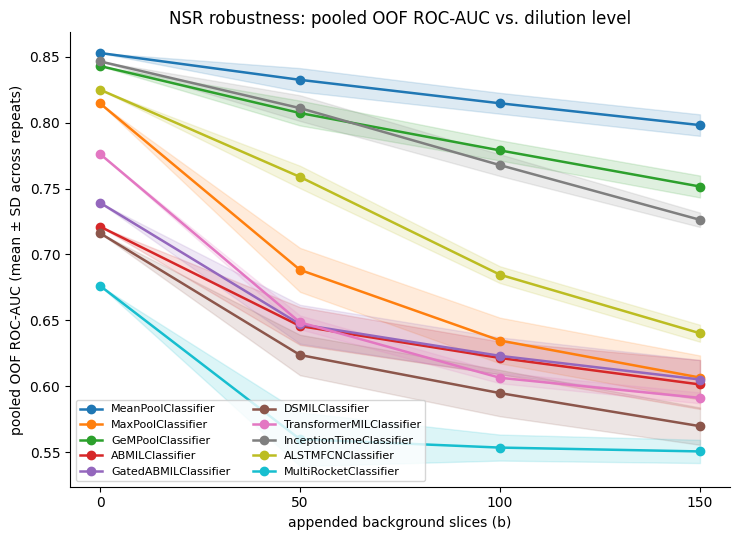

In [17]:
if NSR_ENABLED:
    heads_order = list(HEAD_SEARCH_SPACES.keys())
    b_levels = [0] + list(NSR_DILUTION_LEVELS)
    colors = plt.cm.tab10(np.linspace(0, 1, len(heads_order)))

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    for color, head_name in zip(colors, heads_order):
        sub = nsr_summary_df[nsr_summary_df["head"] == head_name].set_index("b").loc[b_levels]
        mean, sd = sub["mean_roc_auc"].to_numpy(), sub["sd_roc_auc"].to_numpy()
        ax.plot(b_levels, mean, marker="o", color=color, label=head_name, linewidth=1.8)
        ax.fill_between(b_levels, mean - sd, mean + sd, color=color, alpha=0.15)
    ax.set_xlabel("appended background slices (b)")
    ax.set_ylabel("pooled OOF ROC-AUC (mean ± SD across repeats)")
    ax.set_xticks(b_levels)
    ax.set_title("NSR robustness: pooled OOF ROC-AUC vs. dilution level")
    ax.legend(fontsize=8, loc="lower left", ncol=2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(NSR_ROC_PLOT_PATH, dpi=150)
    plt.show()

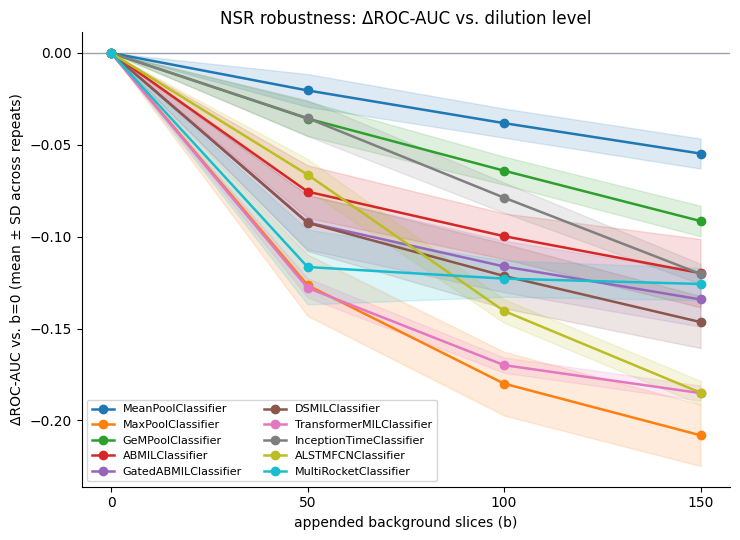

In [18]:
if NSR_ENABLED:
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    for color, head_name in zip(colors, heads_order):
        sub = nsr_summary_df[nsr_summary_df["head"] == head_name].set_index("b").loc[b_levels]
        mean, sd = sub["mean_delta_roc_auc"].to_numpy(), sub["sd_delta_roc_auc"].to_numpy()
        ax.plot(b_levels, mean, marker="o", color=color, label=head_name, linewidth=1.8)
        ax.fill_between(b_levels, mean - sd, mean + sd, color=color, alpha=0.15)
    ax.axhline(0, color="#9CA3AF", linewidth=1, zorder=0)
    ax.set_xlabel("appended background slices (b)")
    ax.set_ylabel("ΔROC-AUC vs. b=0 (mean ± SD across repeats)")
    ax.set_xticks(b_levels)
    ax.set_title("NSR robustness: ΔROC-AUC vs. dilution level")
    ax.legend(fontsize=8, loc="lower left", ncol=2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(NSR_DELTA_PLOT_PATH, dpi=150)
    plt.show()

## Results

**Primary table:** Step 6's pooled-OOF results table — `head`,
`roc_auc_pooled` + 95% CI, `roc_auc_fold_mean` ± std, `auprc_class0`,
`balanced_accuracy` — sorted by pooled ROC-AUC descending, written to
`RESULTS_TABLE_CSV`. The per-scan OOF predictions it's built from live in
`OOF_PREDICTIONS_CSV`, keyed by `scan_id`. `nested_cv_summary.csv` (Step 5)
and `nested_cv_checkpoint.json` (raw per-fold metrics) remain as
supplementary per-fold detail so nothing needs to be reproduced by
re-running the whole search.

**NSR robustness analysis** (Step 7, if `nsr.enabled: true`):
`NSR_SUMMARY_CSV` — mean/SD ROC-AUC, AUPRC, and balanced accuracy (and
their Δ vs. `b=0`) per head per dilution level, across `NSR_N_REPEATS`
random background draws — plus the two figures `NSR_ROC_PLOT_PATH` /
`NSR_DELTA_PLOT_PATH`. `NSR_OOF_PREDICTIONS_CSV` has the underlying
per-scan predictions and Δlogit. `NSR_MANIFEST_CSV` is a compact seed
manifest — one row per `(outer_fold, repeat, scan_id)`, since the exact
background draw is fully reproducible from that seed; the exact 150-slice
selections themselves (if needed without recomputation) live in
`NSR_SELECTIONS_PARQUET`. Each test scan's background set is independently
sampled — never one set shared across the whole fold/repeat.

## Troubleshooting

- **FileNotFoundError on `H5_PATH`:** run `prepare_hdf5_embeddings.ipynb`
  first, or point `experiment.yaml`'s `data.h5_path` at your own embedding
  store.
- **`validate_h5` raises "No samples with split='train'/'test'"**: the store
  needs at least one sample in each of the `train` and `test` splits (even
  though this notebook pools all splits together afterward).
- **CUDA not available:** `DEVICE` falls back to `"cpu"` automatically — the
  neural heads just train much more slowly; expect the run to take
  considerably longer than the GPU estimate in Step 4.
- **`MultiRocketClassifier` ImportError:** this head needs `aeon`
  (`pip install aeon`).
- **Kernel/terminal closed mid-run:** re-running the notebook from Step 4
  restarts the search from scratch; `CHECKPOINT_PATH` and
  `OOF_CHECKPOINT_PATH` hold whatever per-fold metrics and per-scan OOF
  predictions were written before the interruption if you want to inspect
  partial results instead of waiting for a full rerun.
- **`ValueError` from a search's inner CV (too few samples per class):** a
  head's internal early-stopping validation split (or the inner 3-fold
  split itself) needs at least a couple of samples per class in every fold;
  this dataset's class balance is large enough that it shouldn't occur, but
  a much smaller custom dataset could trigger it.
- **Changing what gets searched:** edit `experiment.yaml` — `heads.<name>.enabled`
  to add/drop a head, `heads.<name>.hyperparameters` to change its grid.
  Nothing in this notebook needs to change to pick that up.
- **Skipping the NSR robustness analysis (Step 7):** set `nsr.enabled: false`
  in `experiment.yaml`. Steps 1-6 and their outputs are entirely unaffected
  either way.
- **`ValueError: No class-0 scans found in the outer-train partition`
  (Step 7a) / `ValueError: Background pool has only N eligible slices, need
  M` (Step 7b):** the outer-train partition for that fold doesn't have
  enough class-0 (negative) slices to draw `max(nsr.dilution_levels)`
  background slices from. Lower `nsr.dilution_levels` or use a dataset with
  more class-0 scans.
- **Step 7 re-run after re-running Step 4:** Step 4 always overwrites
  `NSR_FROZEN_MODELS_DIR` with a freshly refit model per fold/head before
  Step 7 runs, so frozen models and Steps 1-6's results stay in sync; there
  is no separate resume/checkpoint path for Step 7 itself (its diluted
  inference is cheap — no training — so a full Step 7 re-run is fast).

## Conclusion

In this notebook we pooled the full prepared embedding store, built
reproducible 5-fold outer / 3-fold inner `StratifiedKFold` splits, and ran
`GridSearchCV`/`RandomizedSearchCV` directly on every enabled `sliceheads`
classification head — no wrapper, since every head is a real sklearn
estimator — using the per-head hyperparameter grids and search strategy
defined in `experiment.yaml`. Beyond the usual per-fold aggregate metrics,
we captured each scan's out-of-fold predicted probability and pooled them
into one N=1063-length vector per head, aligned by scan ID, to report a
pooled ROC-AUC with a stratified bootstrap CI alongside the per-fold
mean ± std, pooled AUPRC (class 0 positive), and pooled balanced accuracy.
The same workflow applies to a different dataset or head subset: point
`experiment.yaml`'s `data.h5_path` at another store, or toggle heads'
`enabled` flags.

Step 7 then reused those same outer folds and each fold's frozen
best-fitted model — never retrained — to run the **Noise-to-Signal Ratio
(NSR) Robustness Analysis**: appending 50/100/150 task-irrelevant
background slices to every outer-test scan, over 10 random repeats, and
reporting how much pooled ROC-AUC/AUPRC/balanced accuracy degrade relative
to the undiluted baseline. Each test scan draws its own independently
sampled background set (never one set shared across a whole fold/repeat)
from class-0 scans in that fold's outer-training partition, so aggregation
heads can't gain an unfair advantage from every scan absorbing identical
injected slices. Toggle it off with `nsr.enabled: false` without affecting
anything above.